In [69]:
import pandas as pd
import numpy as np
import os
import sys

In [70]:
data_path = os.path.join(os.getcwd(), 'data', 'content based')
data_path

'/Users/thescalers-lptp-018/Desktop/Samarth/Projects/DataScience/Recommendation Systems/data/content based'

In [71]:
column_names = ['user_id', 'movie_id', 'rating', 'timestamp']
ratings = pd.read_csv(os.path.join(data_path, 'u.data'), sep='\t', names=column_names)
ratings.head(10)

,user_id,movie_id,rating,timestamp
0,0,50,5,881250949
1,0,172,5,881250949
2,0,133,1,881250949
3,196,242,3,881250949
4,186,302,3,891717742
5,22,377,1,878887116
6,244,51,2,880606923
7,166,346,1,886397596
8,298,474,4,884182806
9,115,265,2,881171488


In [72]:
titles = pd.read_csv(os.path.join(data_path, 'Movie_Id_Titles.txt'))
titles.rename(columns={'item_id': 'movie_id'}, inplace=True)
titles.head(10)

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)
5,6,Shanghai Triad (Yao a yao yao dao waipo qiao) ...
6,7,Twelve Monkeys (1995)
7,8,Babe (1995)
8,9,Dead Man Walking (1995)
9,10,Richard III (1995)


In [73]:
merged = pd.merge(ratings, titles, on='movie_id', how='left').reset_index(drop=True)
merged.head(10)

,user_id,movie_id,rating,timestamp,title
0,0,50,5,881250949,Star Wars (1977)
1,0,172,5,881250949,"Empire Strikes Back, The (1980)"
2,0,133,1,881250949,Gone with the Wind (1939)
3,196,242,3,881250949,Kolya (1996)
4,186,302,3,891717742,L.A. Confidential (1997)
5,22,377,1,878887116,Heavyweights (1994)
6,244,51,2,880606923,Legends of the Fall (1994)
7,166,346,1,886397596,Jackie Brown (1997)
8,298,474,4,884182806,Dr. Strangelove or: How I Learned to Stop Worr...
9,115,265,2,881171488,"Hunt for Red October, The (1990)"


In [74]:
merged.drop(columns=['timestamp'], axis=1, inplace=True)

In [75]:
merged.head(10)

,user_id,movie_id,rating,title
0,0,50,5,Star Wars (1977)
1,0,172,5,"Empire Strikes Back, The (1980)"
2,0,133,1,Gone with the Wind (1939)
3,196,242,3,Kolya (1996)
4,186,302,3,L.A. Confidential (1997)
5,22,377,1,Heavyweights (1994)
6,244,51,2,Legends of the Fall (1994)
7,166,346,1,Jackie Brown (1997)
8,298,474,4,Dr. Strangelove or: How I Learned to Stop Worr...
9,115,265,2,"Hunt for Red October, The (1990)"


In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

In [77]:
merged.groupby('title')['rating'].mean().sort_values(ascending=False).head(10)

title
They Made Me a Criminal (1939)                       5.0
Marlene Dietrich: Shadow and Light (1996)            5.0
Saint of Fort Washington, The (1993)                 5.0
Someone Else's America (1995)                        5.0
Star Kid (1997)                                      5.0
Great Day in Harlem, A (1994)                        5.0
Aiqing wansui (1994)                                 5.0
Santa with Muscles (1996)                            5.0
Prefontaine (1997)                                   5.0
Entertaining Angels: The Dorothy Day Story (1996)    5.0
Name: rating, dtype: float64

In [78]:
merged.groupby('title')['rating'].count().sort_values(ascending=False).head(10)

title
Star Wars (1977)                 584
Contact (1997)                   509
Fargo (1996)                     508
Return of the Jedi (1983)        507
Liar Liar (1997)                 485
English Patient, The (1996)      481
Scream (1996)                    478
Toy Story (1995)                 452
Air Force One (1997)             431
Independence Day (ID4) (1996)    429
Name: rating, dtype: int64

In [79]:
ratings = merged.groupby('title')['rating'].mean().reset_index()
ratings['num ratings'] = merged.groupby('title')['rating'].count().values
ratings.head(10)

,title,rating,num ratings
0,'Til There Was You (1997),2.333333,9
1,1-900 (1994),2.600000,5
2,101 Dalmatians (1996),2.908257,109
3,12 Angry Men (1957),4.344000,125
4,187 (1997),3.024390,41
5,2 Days in the Valley (1996),3.225806,93
6,"20,000 Leagues Under the Sea (1954)",3.500000,72
7,2001: A Space Odyssey (1968),3.969112,259
8,3 Ninjas: High Noon At Mega Mountain (1998),1.000000,5
9,"39 Steps, The (1935)",4.050847,59


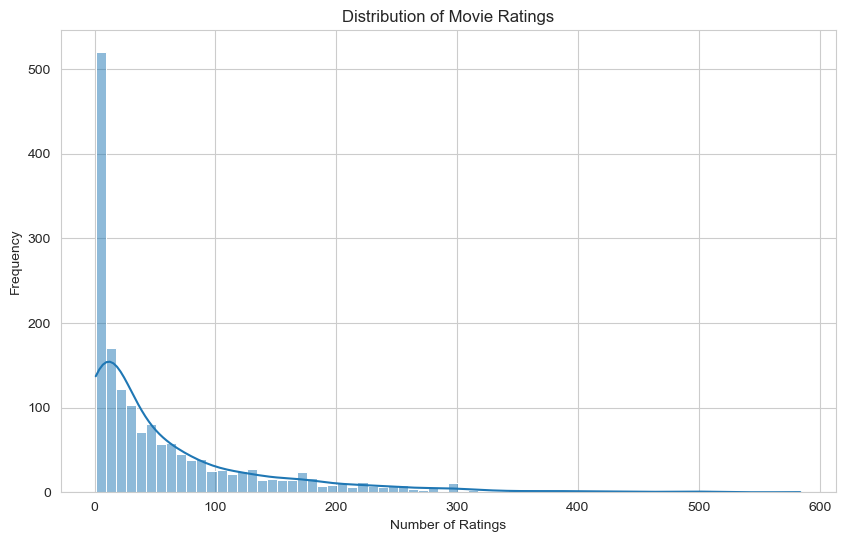

In [80]:
plt.figure(figsize=(10, 6))
sns.histplot(ratings['num ratings'], bins=70, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency')
plt.show()

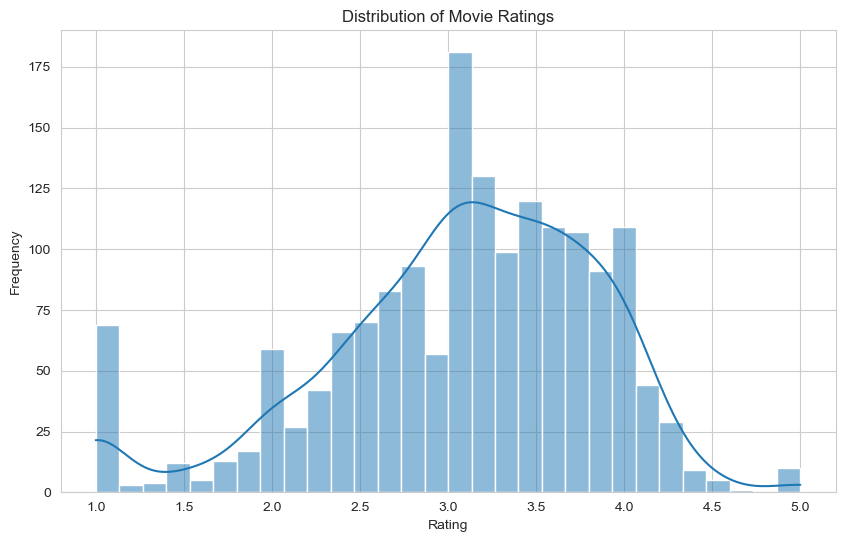

In [81]:
plt.figure(figsize=(10, 6))
sns.histplot(ratings['rating'], bins=30, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

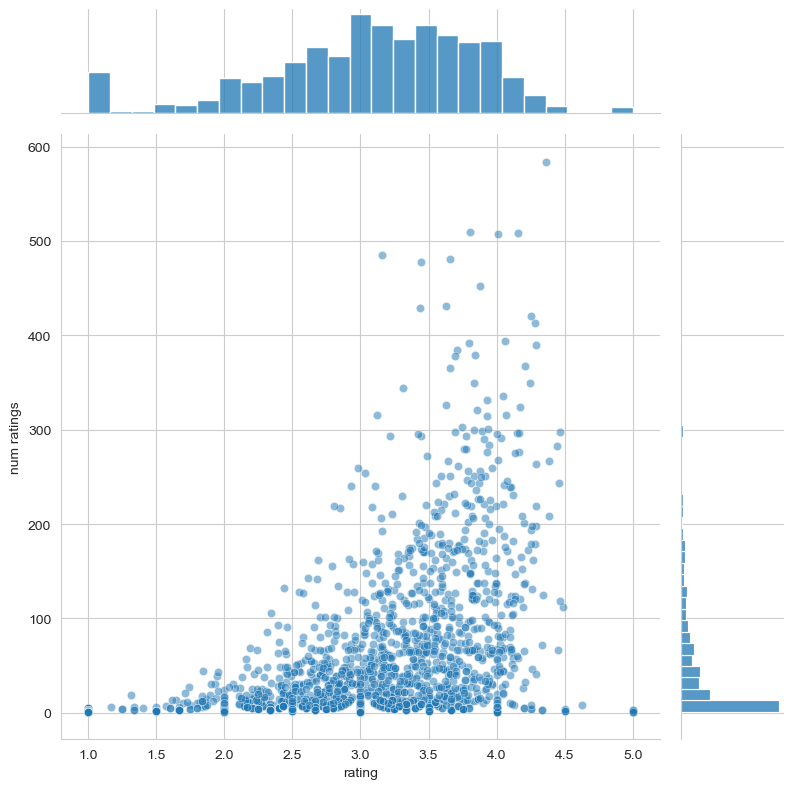

In [82]:
sns.jointplot(x='rating', y='num ratings', data=ratings, kind='scatter', height=8, alpha=0.5)

In [83]:
pivot = merged.pivot_table(index='user_id', columns='title', values='rating', fill_value=0)
pivot.head(10)

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,2.0,5.0,0.0,0.0,3.0,4.0,0.0,0.0,...,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,2.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,4.0,0.0
6,0.0,0.0,0.0,4.0,0.0,0.0,0.0,5.0,0.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,4.0,0.0,0.0,5.0,5.0,0.0,4.0,...,0.0,0.0,0.0,5.0,3.0,0.0,3.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [84]:
ratings.sort_values('num ratings', ascending=False).head(10)

,title,rating,num ratings
1398,Star Wars (1977),4.359589,584
333,Contact (1997),3.803536,509
498,Fargo (1996),4.155512,508
1234,Return of the Jedi (1983),4.007890,507
860,Liar Liar (1997),3.156701,485
460,"English Patient, The (1996)",3.656965,481
1284,Scream (1996),3.441423,478
1523,Toy Story (1995),3.878319,452
32,Air Force One (1997),3.631090,431
744,Independence Day (ID4) (1996),3.438228,429


In [85]:
# pick two movies at random to get correlation of user interactions
movie1 = 'Star Wars (1977)'
movie2 = 'Contact (1997)'
movie1_ratings = pivot[movie1]
movie2_ratings = pivot[movie2]
similar_to_movie1 = pivot.corrwith(movie1_ratings)
similar_to_movie2 = pivot.corrwith(movie2_ratings)
corr_movie1 = pd.DataFrame(similar_to_movie1, columns=['Correlation'])
corr_movie2 = pd.DataFrame(similar_to_movie2, columns=['Correlation'])
corr_movie1.dropna(inplace=True)
corr_movie2.dropna(inplace=True)


# this indicatses how similar the ratings are for the two movies
# corr_movie1 indicates how similar the ratings are for 'Star Wars (1977)' and recommends similar movies
# corr_movie2 indicates how similar the ratings are for 'Contact (1997)' and recommends similar movies
ratings = ratings.set_index('title')          # <- key line
corr_movie1 = corr_movie1.join(ratings['num ratings'])
corr_movie1.sort_values('Correlation', ascending=False).head(10)

,Correlation,num ratings
title,,
Star Wars (1977),1.000000,584
Return of the Jedi (1983),0.746797,507
"Empire Strikes Back, The (1980)",0.555233,368
Raiders of the Lost Ark (1981),0.540455,420
Indiana Jones and the Last Crusade (1989),0.467523,331
Toy Story (1995),0.456219,452
"Terminator, The (1984)",0.437866,301
Back to the Future (1985),0.419493,350
Alien (1979),0.412516,291


In [86]:
corr_movie1[corr_movie1['num ratings'] > 100].sort_values('Correlation', ascending=False).head(10)

,Correlation,num ratings
title,,
Star Wars (1977),1.000000,584
Return of the Jedi (1983),0.746797,507
"Empire Strikes Back, The (1980)",0.555233,368
Raiders of the Lost Ark (1981),0.540455,420
Indiana Jones and the Last Crusade (1989),0.467523,331
Toy Story (1995),0.456219,452
"Terminator, The (1984)",0.437866,301
Back to the Future (1985),0.419493,350
Alien (1979),0.412516,291


In [87]:
corr_movie2 = corr_movie2.join(ratings['num ratings'])
corr_movie2.sort_values('Correlation', ascending=False).head(10)

,Correlation,num ratings
title,,
Contact (1997),1.000000,509
"Saint, The (1997)",0.293838,316
Air Force One (1997),0.271920,431
Conspiracy Theory (1997),0.271862,295
G.I. Jane (1997),0.269960,175
"Game, The (1997)",0.260542,251
Starship Troopers (1997),0.255116,211
Star Trek: First Contact (1996),0.232719,365
Titanic (1997),0.230975,350


In [88]:
corr_movie2[corr_movie2['num ratings'] > 100].sort_values('Correlation', ascending=False).head(10)

,Correlation,num ratings
title,,
Contact (1997),1.000000,509
"Saint, The (1997)",0.293838,316
Air Force One (1997),0.271920,431
Conspiracy Theory (1997),0.271862,295
G.I. Jane (1997),0.269960,175
"Game, The (1997)",0.260542,251
Starship Troopers (1997),0.255116,211
Star Trek: First Contact (1996),0.232719,365
Titanic (1997),0.230975,350
